In [91]:
import pandas as pd
import mygene
import networkx as nx
import re
from scipy import stats
from statsmodels.stats.multitest import multipletests
# from scipy.stats import ttest_ind    # t-test for p-values
from scipy.stats import mannwhitneyu # Mann-Whitney U for p-values
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import gseapy as gp
import requests, time
import pandas as pd
import os

### Step 1. Prune the gene list by removing all genes that do not have expression above 1 TPM in at least 3 samples.

TPM (Transcripts Per Million): a normalized measure of gene expression in RNA-Seq data.<br />
It estimates how abundant a gene’s transcripts are relative to all transcripts in the sample.

In [92]:
tpm_filtered = pd.read_csv("step1/GSE78220_norm_counts_TPM_GRCh38.p13_NCBI.tsv", sep="\t")

mask = (tpm_filtered.iloc[:, 1:] > 1).sum(axis=1) >= 3
# 1: bc the first column is gene names, so we start from index 1
# () > 1: check if TPM is greater than 1
# .sum(axis=1): count how many samples have TPM > 1 for each gene
# >= 3: keep genes that have TPM > 1 in at least 3 samples
# in the end, we get a boolean vector (mask) that indicates which genes pass the filter 
# column: e.g. TRUE TRUE FALSE TRUE ...

filtered_genes = tpm_filtered.loc[mask]
# keep the TRUE rows

print(filtered_genes.shape)
filtered_genes.head()

(20193, 29)


,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069841,GSM2069842,GSM2069843,GSM2069844,GSM2069845,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850
1,653635,14.580,8.5530,16.6500,30.0400,13.6400,23.90,20.870,21.74,23.1100,...,20.0300,13.590,15.620,17.290,18.20,16.1000,27.240,16.99,15.080,24.970
2,102466751,9.791,3.9530,14.9500,6.8840,34.9600,23.60,22.380,16.45,17.9400,...,6.8280,8.803,22.600,12.510,33.23,9.0920,34.460,11.60,7.157,23.430
8,729737,1.238,0.8699,0.5833,0.9341,0.8281,1.98,1.709,3.09,0.9256,...,0.8779,2.277,3.012,7.225,2.13,0.6511,2.671,2.76,0.563,1.530
10,102723897,19.300,7.7200,15.9700,52.8200,17.0600,22.46,26.340,24.30,26.2900,...,21.4400,16.880,20.060,21.410,23.47,18.0900,34.040,24.44,16.470,25.250
11,102465909,5.786,2.8240,9.8690,3.7070,20.7400,10.59,10.780,11.31,8.1920,...,3.0730,3.827,9.453,6.254,13.48,3.7440,13.100,12.18,3.340,9.808


### Step 2. Next, obtain the network connecting only the genes that survived the filter in step 1. In this pruned network, compute the node degree (ND) and the betweenness centrality (BC) for all nodes that survived Step 1.

#### 2.1 Map Entrez GeneID (e.g. 7157) to gene symbol (e.g. TP53)

In [95]:
# combined_score_threshold = 700 # arbitrarily set
links = pd.read_csv("step2/9606.protein.links.v12.0.txt", sep=" ")
# links = links[links["combined_score"] > combined_score_threshold]

print(links.shape)
links.head()

(13715404, 3)


,protein1,protein2,combined_score
0,9606.ENSP00000000233,9606.ENSP00000356607,173
1,9606.ENSP00000000233,9606.ENSP00000427567,154
2,9606.ENSP00000000233,9606.ENSP00000253413,151
3,9606.ENSP00000000233,9606.ENSP00000493357,471
4,9606.ENSP00000000233,9606.ENSP00000324127,201


Entrez IDs are unique numerical identifiers for genes in the NCBI Gene database.

In [98]:
entrez_ids = filtered_genes["GeneID"].tolist()
entrez_ids[:5]

[653635, 102466751, 729737, 102723897, 102465909]

In [99]:
mg = mygene.MyGeneInfo()  

results = mg.querymany(
    entrez_ids,
    scopes="entrezgene", # input IDs are Entrez Gene IDs
    fields="symbol",     # return gene symbols
    species="human"
)

results[:5]


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
355 input query terms found no hit:	['100133331', '107984841', '107984847', '107984849', '107985733', '107985734', '105376725', '1053767


[{'query': '653635', '_id': '653635', '_score': 8.8298025, 'symbol': 'WASH7P'},
 {'query': '102466751',
  '_id': '102466751',
  '_score': 27.36807,
  'symbol': 'MIR6859-1'},
 {'query': '729737',
  '_id': '729737',
  '_score': 27.370037,
  'symbol': 'LOC729737'},
 {'query': '102723897',
  '_id': '102723897',
  '_score': 8.829044,
  'symbol': 'LOC102723897'},
 {'query': '102465909',
  '_id': '102465909',
  '_score': 27.367456,
  'symbol': 'MIR6859-2'}]

In [100]:
filtered_genes = filtered_genes.drop_duplicates(subset="GeneID")

mapping = {}

for r in results:
    if "symbol" in r:
        mapping[r["query"]] = r["symbol"]

list(mapping.items())[:10]

[('653635', 'WASH7P'),
 ('102466751', 'MIR6859-1'),
 ('729737', 'LOC729737'),
 ('102723897', 'LOC102723897'),
 ('102465909', 'MIR6859-2'),
 ('100132287', 'LOC100132287'),
 ('113219467', 'MIR12136'),
 ('100288069', 'LOC100288069'),
 ('79854', 'LINC00115'),
 ('643837', 'LINC01128')]

In [101]:
# adds a new column with gene symbols to filtered_genes
filtered_genes["symbol"] = filtered_genes["GeneID"].astype(str).map(mapping)

filtered_genes.head()

,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069842,GSM2069843,GSM2069844,GSM2069845,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850,symbol
1,653635,14.580,8.5530,16.6500,30.0400,13.6400,23.90,20.870,21.74,23.1100,...,13.590,15.620,17.290,18.20,16.1000,27.240,16.99,15.080,24.970,WASH7P
2,102466751,9.791,3.9530,14.9500,6.8840,34.9600,23.60,22.380,16.45,17.9400,...,8.803,22.600,12.510,33.23,9.0920,34.460,11.60,7.157,23.430,MIR6859-1
8,729737,1.238,0.8699,0.5833,0.9341,0.8281,1.98,1.709,3.09,0.9256,...,2.277,3.012,7.225,2.13,0.6511,2.671,2.76,0.563,1.530,LOC729737
10,102723897,19.300,7.7200,15.9700,52.8200,17.0600,22.46,26.340,24.30,26.2900,...,16.880,20.060,21.410,23.47,18.0900,34.040,24.44,16.470,25.250,LOC102723897
11,102465909,5.786,2.8240,9.8690,3.7070,20.7400,10.59,10.780,11.31,8.1920,...,3.827,9.453,6.254,13.48,3.7440,13.100,12.18,3.340,9.808,MIR6859-2


#### 2.2 Prune the STRING network to keep only edges between your filtered genes

In [102]:
info = pd.read_csv("step2/9606.protein.info.v12.0.txt", sep="\t")

# Keep only the columns we need & change column names 
info = info[["#string_protein_id", "preferred_name"]]

# rename for clarity
info.columns = ["string_id", "symbol"]    
filtered_genes.head()

,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069842,GSM2069843,GSM2069844,GSM2069845,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850,symbol
1,653635,14.580,8.5530,16.6500,30.0400,13.6400,23.90,20.870,21.74,23.1100,...,13.590,15.620,17.290,18.20,16.1000,27.240,16.99,15.080,24.970,WASH7P
2,102466751,9.791,3.9530,14.9500,6.8840,34.9600,23.60,22.380,16.45,17.9400,...,8.803,22.600,12.510,33.23,9.0920,34.460,11.60,7.157,23.430,MIR6859-1
8,729737,1.238,0.8699,0.5833,0.9341,0.8281,1.98,1.709,3.09,0.9256,...,2.277,3.012,7.225,2.13,0.6511,2.671,2.76,0.563,1.530,LOC729737
10,102723897,19.300,7.7200,15.9700,52.8200,17.0600,22.46,26.340,24.30,26.2900,...,16.880,20.060,21.410,23.47,18.0900,34.040,24.44,16.470,25.250,LOC102723897
11,102465909,5.786,2.8240,9.8690,3.7070,20.7400,10.59,10.780,11.31,8.1920,...,3.827,9.453,6.254,13.48,3.7440,13.100,12.18,3.340,9.808,MIR6859-2


In [103]:
# Map your filtered genes to STRING IDs 
filtered_genes = filtered_genes.merge(info, on="symbol", how="inner")
# This uses the "symbol" column as the key to match rows in both data frames, i.e. info, filtered_genes.
 
filtered_genes.head()

,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069843,GSM2069844,GSM2069845,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850,symbol,string_id
0,148398,8.7230,2.6880,1.67800,4.02800,1.8470,7.4030,7.80300,4.62900,11.2000,...,4.3280,9.341,4.098,28.360,45.940,15.3000,10.300,8.02800,SAMD11,9606.ENSP00000342313
1,26155,119.4000,28.7600,34.85000,74.85000,42.4000,51.4800,57.12000,49.73000,89.3300,...,46.7000,71.460,37.150,205.000,62.120,146.5000,72.340,47.71000,NOC2L,9606.ENSP00000317992
2,339451,9.3650,0.7969,1.37800,8.98900,1.5960,6.5960,1.58200,2.01900,22.8000,...,7.3520,4.650,5.896,5.804,23.310,5.7300,4.010,3.72000,KLHL17,9606.ENSP00000343930
3,84069,1.6020,1.0260,0.01016,0.08991,0.1266,0.3352,0.11260,0.27340,4.8550,...,1.3680,11.440,15.190,2.824,4.400,0.4925,1.304,0.23130,PLEKHN1,9606.ENSP00000368720
4,84808,0.2009,0.1593,0.02813,0.40840,0.2368,0.3442,0.03118,0.07734,0.8145,...,0.8427,2.804,29.160,1.479,1.141,0.4256,1.131,0.07175,PERM1,9606.ENSP00000414022


In [104]:
# This set contains the proteins that are in the filtered_genes
valid_string_ids = set(filtered_genes["string_id"])
# print(f"Nr of Genes with STRING mapping: {len(valid_string_ids)}")

# Filter the STRING links to keep only edges between surviving genes
pruned_links = links[
    links["protein1"].isin(valid_string_ids) &
    links["protein2"].isin(valid_string_ids)
].copy()

# print(f"Nr of Edges in pruned network: {len(pruned_links)}")
pruned_links.head()
# links columns are: protein1, protein2, combined_score

,protein1,protein2,combined_score
0,9606.ENSP00000000233,9606.ENSP00000356607,173
1,9606.ENSP00000000233,9606.ENSP00000427567,154
2,9606.ENSP00000000233,9606.ENSP00000253413,151
3,9606.ENSP00000000233,9606.ENSP00000493357,471
4,9606.ENSP00000000233,9606.ENSP00000324127,201


#### 2.3 Compute node degree (ND) and betweenness centrality (BC)

In [105]:
G = nx.from_pandas_edgelist(
    pruned_links,
    source="protein1",
    target="protein2",
    edge_attr="combined_score"
)

In [ ]:
# wanted to see visualization - takes too long
# plt.figure(figsize=(10,10))
# nx.draw(G, with_labels=False, node_size=5) # with_labels is too slow, so set to False #node_size=5 already takes 5min to run
# plt.show()

2.3.1 Node Degree: number of connections a node has.

In [106]:
# Add any surviving genes that have NO edges (isolated nodes)
G.add_nodes_from(valid_string_ids)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# Compute Node Degree (ND)
nd = dict(G.degree())  # {string_id: degree}

Nodes: 14591, Edges: 4952508


2.3.2 Betweenness Centrality: how often a node lies on the shortest path between other nodes.

In [107]:
# Compute Betweenness Centrality (BC)
# bc = nx.betweenness_centrality(G, normalized=True)   # {string_id: bc_value} # takes too long

# If too slow, use: 
bc = nx.betweenness_centrality(G, k=500, normalized=True) 
# This approximates betweenness centrality by sampling only k nodes instead of using all nodes.

KeyboardInterrupt: 

filtered_genes dataframe with ND and BC attached on the right side

In [ ]:
# Attach ND and BC 
filtered_genes["ND"] = filtered_genes["string_id"].map(nd)
filtered_genes["BC"] = filtered_genes["string_id"].map(bc)

# Nodes not in the graph get 0
filtered_genes["ND"] = filtered_genes["ND"].fillna(0)
filtered_genes["BC"] = filtered_genes["BC"].fillna(0)

filtered_genes.head()

,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069845,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850,symbol,string_id,ND,BC
0,148398,8.7230,2.6880,1.67800,4.02800,1.8470,7.4030,7.80300,4.62900,11.2000,...,4.098,28.360,45.940,15.3000,10.300,8.02800,SAMD11,9606.ENSP00000342313,0,0.000000
1,26155,119.4000,28.7600,34.85000,74.85000,42.4000,51.4800,57.12000,49.73000,89.3300,...,37.150,205.000,62.120,146.5000,72.340,47.71000,NOC2L,9606.ENSP00000317992,186,0.000496
2,339451,9.3650,0.7969,1.37800,8.98900,1.5960,6.5960,1.58200,2.01900,22.8000,...,5.896,5.804,23.310,5.7300,4.010,3.72000,KLHL17,9606.ENSP00000343930,1,0.000000
3,84069,1.6020,1.0260,0.01016,0.08991,0.1266,0.3352,0.11260,0.27340,4.8550,...,15.190,2.824,4.400,0.4925,1.304,0.23130,PLEKHN1,9606.ENSP00000368720,0,0.000000
4,84808,0.2009,0.1593,0.02813,0.40840,0.2368,0.3442,0.03118,0.07734,0.8145,...,29.160,1.479,1.141,0.4256,1.131,0.07175,PERM1,9606.ENSP00000414022,1,0.000000


### Step 3. Compute the p-values and log2 FC for genes surviving Step 1. To this end, use the gene expression data in (normalized/raw) counts. Correct the significance of the p-values using Benjamini-Hochberg correction. Generate a volcano plot and perform a principal component analysis

Side note: 
- Fold Change (FC) measures how much a gene’s expression differs between two groups
$$
FC = \frac{\text{mean expression in group 2}}{\text{mean expression in group 1}}
$$

- P-value: probability that the observed difference happened by chance.
- Benjamini-Hochberg (BH) correction Adjusts p-values for multiple testing.
- Volcano plot = scatter plot of:

    - x-axis: log2 FC

    - y-axis: -log10(p-value)
- PCA: Uses gene expression to see if samples cluster by group (PD, PR, CR).

#### 3.1 From GSE78220_series_matrix extract response types (PD, PR, CR) and map them to GSM_ID.

3.1.1 Extract patient IDs and anti-PD-1 response 

In [ ]:
file = "step3/GSE78220_series_matrix.txt"

with open(file, "r") as f:
    lines = f.readlines()

# extract patient IDs and anti-PD-1 response from the !Sample_characteristics_ch1 line
char_lines = [line.strip() for line in lines if line.startswith("!Sample_characteristics_ch1")]
patient_line = char_lines[0].split("\t")[1:]   # skip header
response_line = char_lines[1].split("\t")[1:]  # skip header

# clean quotes and extract values
patients = [re.search(r"patient id: (.+?)$", x).group(1).replace('"','') for x in patient_line]
responses = [re.search(r"anti-pd-1 response: (.+?)$", x).group(1).replace('"','') for x in response_line]

# map patient ID to response
group_info = dict(zip(patients, responses))
group_info

{'Pt1': 'Progressive Disease',
 'Pt2': 'Partial Response',
 'Pt4': 'Partial Response',
 'Pt5': 'Partial Response',
 'Pt6': 'Partial Response',
 'Pt7': 'Progressive Disease',
 'Pt8': 'Complete Response',
 'Pt9': 'Complete Response',
 'Pt10': 'Progressive Disease',
 'Pt12': 'Progressive Disease',
 'Pt13': 'Complete Response',
 'Pt14': 'Progressive Disease',
 'Pt15': 'Partial Response',
 'Pt16': 'Progressive Disease',
 'Pt19': 'Partial Response',
 'Pt20': 'Progressive Disease',
 'Pt22': 'Progressive Disease',
 'Pt23': 'Progressive Disease',
 'Pt25': 'Progressive Disease',
 'Pt27': 'Complete Response',
 'Pt28': 'Partial Response',
 'Pt29': 'Progressive Disease',
 'Pt31': 'Progressive Disease',
 'Pt32': 'Progressive Disease',
 'Pt35': 'Partial Response',
 'Pt37': 'Partial Response',
 'Pt38': 'Partial Response'}

3.1.2 Extract GSM IDs

In [73]:
# Extract GSM IDs from !Sample_geo_accession line
gsm_line = [line.strip() for line in lines if line.startswith("!Sample_geo_accession")][0]
gsm_ids = gsm_line.split("\t")[1:]  # skip header
gsm_ids = [x.replace('"','') for x in gsm_ids]  # clean quotes

3.1.3 Map responses to GSM IDs 

In [113]:
# Map patient to GSM 
patient_to_gsm = dict(zip(patients, gsm_ids))

# Map GSM to response 
gsm_group_info = {patient_to_gsm[p]: r for p, r in zip(patients, responses)}

# Separate GSM IDs by response 
pd_gsm = [g for g in gsm_group_info if gsm_group_info[g] == "Progressive Disease"]
# pr_gsm = [g for g in gsm_group_info if gsm_group_info[g] == "Partial Response"]
cr_gsm = [g for g in gsm_group_info if gsm_group_info[g] == "Complete Response" or gsm_group_info[g] == "Partial Response"]

pd_gsm[:5], cr_gsm[:5]; #pr_gsm[:5]

# question: pr not needed?

#### 3.2 Calculate tests

Side note: 
- The null hypothesis: drugs are the same
- The p-value helps us decide if we should reject the null hypothesis or not.

3.2.1 P-values, log2fc

In [114]:
# Load raw counts
# Row: GeneID
# Columns: patient samples
counts = pd.read_csv("step3/GSE78220_raw_counts_GRCh38.p13_NCBI.tsv", sep="\t")

# Keep only genes that survived Step 1 
counts = counts[counts["GeneID"].isin(filtered_genes["GeneID"])]

# Row: GeneID
# Columns: patient samples
counts = counts.set_index("GeneID") 

# Identify which columns belong to PD and CR
# pd_gsm/cr_gsm: list of sample IDs for PD/CR patients
pd_cols = [c for c in counts.columns if c in pd_gsm] # columns of patients with PD response
cr_cols = [c for c in counts.columns if c in cr_gsm] # columns of patients with CR response

In [115]:
len(pd_cols), len(cr_cols)

(13, 14)

In [116]:
pvals = []  # store p-values for each gene
log2fc = [] # store log2 fold changes for each gene

# Iterates gene-by-gene
# Expression value : “How strongly is this gene turned on in this patient?”
for gene in counts.index:
    pd_expr = counts.loc[gene, pd_cols].values.astype(float) # e.g. GSM2069847: value 2, GSM2069829: value 0, etc.->  size: len(pd_cols) x 2
    cr_expr = counts.loc[gene, cr_cols].values.astype(float) # (cr_cols) x 2
    
    # log2 FC: CR vs PD (positive => higher in CR)
    mean_pd = np.mean(pd_expr)
    mean_cr = np.mean(cr_expr)

    eps = 1e-6 # to avoid log(0)
    fc = np.log2((mean_cr + eps) / (mean_pd + eps))
    log2fc.append(fc)
    
    # Mann-Whitney U test (non-parametric, good for small n)
    # Tests whether CR and PD distributions differ
    try:
        _, p = mannwhitneyu(cr_expr, pd_expr, alternative="two-sided")
    except ValueError:
        p = 1.0
    pvals.append(p)

testing

In [117]:
print(min(pvals))
print(len(pvals)) # nr of genes tested
np.sum(np.array(pvals) < 0.05) # p-values that are small enough

0.0006236972944091846
14591


np.int64(488)

The raw p-values are not very small overall because the sample size is small.

In [ ]:
# log2fc[:5], pvals[:5]   

([np.float64(-1.3041990011685753),
  np.float64(-0.6184697427170162),
  np.float64(-1.0049936276425766),
  np.float64(-1.3050147058275803),
  np.float64(-2.905833259058937)],
 [np.float64(0.10168067226890756),
  np.float64(0.35042016806722687),
  np.float64(0.16302521008403362),
  np.float64(0.35042016806722687),
  np.float64(0.24537815126050422)])

3.2.2 Benjamini-Hochberg (BH) correction

In [118]:
# Multiple testing correction   
reject, pvals_adj, _, _ = multipletests(pvals, method="fdr_bh")

# Attach to filtered_genes
stat_df = pd.DataFrame({
    "GeneID": counts.index,
    "log2FC": log2fc,
    "pval": pvals,
    "pval_adj": pvals_adj
}).reset_index(drop=True)

# GeneID may be int in filtered_genes - match types
stat_df["GeneID"] = stat_df["GeneID"].astype(str)
filtered_genes["GeneID"] = filtered_genes["GeneID"].astype(str)

filtered_genes = filtered_genes.merge(stat_df, on="GeneID", how="left")
filtered_genes.head()

,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850,symbol,string_id,log2FC,pval,pval_adj
0,148398,8.7230,2.6880,1.67800,4.02800,1.8470,7.4030,7.80300,4.62900,11.2000,...,28.360,45.940,15.3000,10.300,8.02800,SAMD11,9606.ENSP00000342313,-1.194270,0.010103,1.0
1,26155,119.4000,28.7600,34.85000,74.85000,42.4000,51.4800,57.12000,49.73000,89.3300,...,205.000,62.120,146.5000,72.340,47.71000,NOC2L,9606.ENSP00000317992,-0.575931,0.114772,1.0
2,339451,9.3650,0.7969,1.37800,8.98900,1.5960,6.5960,1.58200,2.01900,22.8000,...,5.804,23.310,5.7300,4.010,3.72000,KLHL17,9606.ENSP00000343930,-1.107777,0.016304,1.0
3,84069,1.6020,1.0260,0.01016,0.08991,0.1266,0.3352,0.11260,0.27340,4.8550,...,2.824,4.400,0.4925,1.304,0.23130,PLEKHN1,9606.ENSP00000368720,-1.027481,0.027248,1.0
4,84808,0.2009,0.1593,0.02813,0.40840,0.2368,0.3442,0.03118,0.07734,0.8145,...,1.479,1.141,0.4256,1.131,0.07175,PERM1,9606.ENSP00000414022,-2.225922,0.244098,1.0


PROBLEM: all pvals_adj are 1.0

In [119]:
np.sum(pvals_adj != 1)

np.int64(0)

3.2.3 Volcano plot

A volcano plot combines fold change and significance in one view. The x-axis is log2FC and the y-axis is -log10(p-value) (so higher = more significant). Genes that are both strongly changed AND statistically significant appear in the upper-left or upper-right corners.

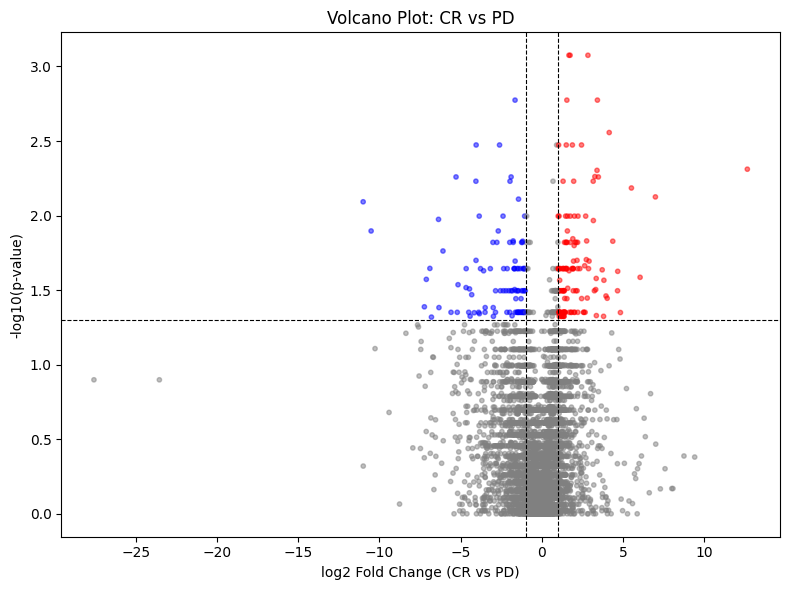

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

neg_log10_p = -np.log10(filtered_genes["pval"] + eps)

# Color by significance and fold change
colors = []
for fc, p in zip(filtered_genes["log2FC"], filtered_genes["pval"]):
    if p < 0.05 and fc > 1:
        colors.append("red")       # up in CR
    elif p < 0.05 and fc < -1:
        colors.append("blue")      # up in PD
    else:
        colors.append("grey")

ax.scatter(filtered_genes["log2FC"], neg_log10_p, c=colors, alpha=0.5, s=10)
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
ax.axvline(1, color="black", linestyle="--", linewidth=0.8)
ax.axvline(-1, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("log2 Fold Change (CR vs PD)")
ax.set_ylabel("-log10(p-value)")
ax.set_title("Volcano Plot: CR vs PD")
plt.tight_layout()
plt.show()

PROBLEM: makes no sense with pval_adj

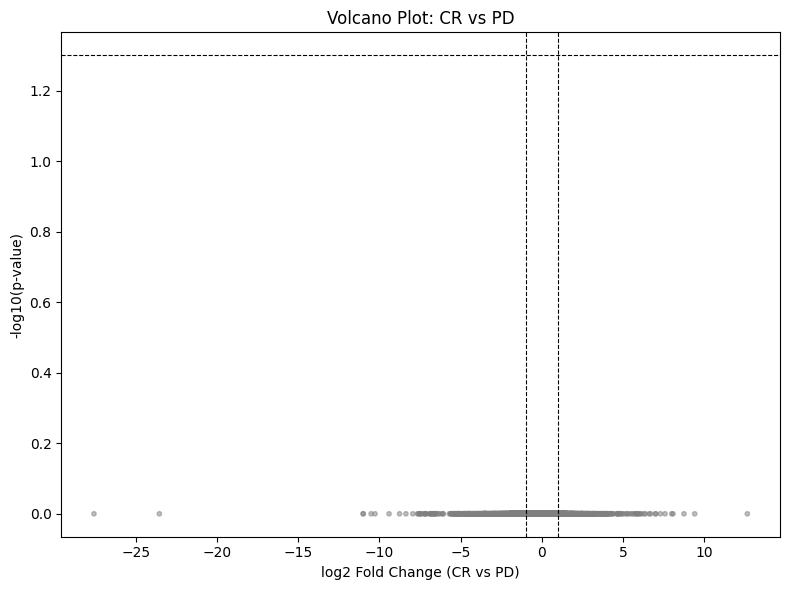

In [88]:
fig, ax = plt.subplots(figsize=(8, 6))

neg_log10_p = -np.log10(filtered_genes["pval_adj"] + eps)

# Color by significance and fold change
colors = []
for fc, p in zip(filtered_genes["log2FC"], filtered_genes["pval_adj"]):
    if p < 0.05 and fc > 1:
        colors.append("red")       # up in CR
    elif p < 0.05 and fc < -1:
        colors.append("blue")      # up in PD
    else:
        colors.append("grey")

ax.scatter(filtered_genes["log2FC"], neg_log10_p, c=colors, alpha=0.5, s=10)
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
ax.axvline(1, color="black", linestyle="--", linewidth=0.8)
ax.axvline(-1, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("log2 Fold Change (CR vs PD)")
ax.set_ylabel("-log10(p-value)")
ax.set_title("Volcano Plot: CR vs PD")
plt.tight_layout()
plt.show()

3.2.4 PCA

Interpretation:
- If PD and CR cluster separately: Responders and non-responders have distinct expression patterns.
- If they overlap heavily: Gene expression alone does not clearly separate the groups.

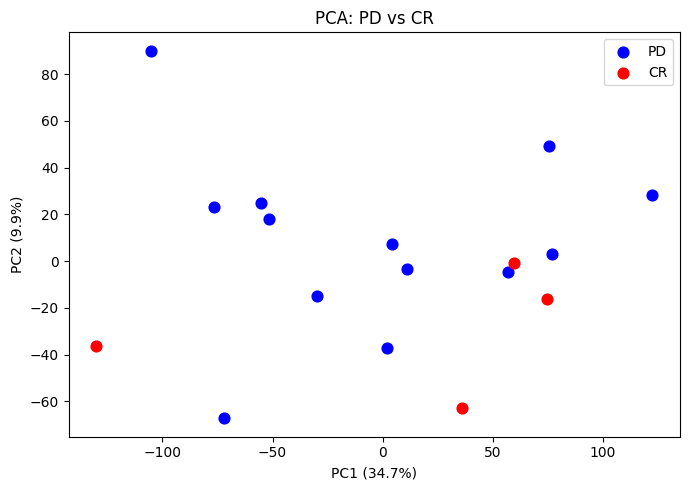

In [ ]:
# Use PD + CR samples only, genes that survived step 1
pca_cols = pd_cols + cr_cols
pca_data = counts[pca_cols].T  # shape: (samples, genes)

# Log-transform + scale
pca_data_log = np.log2(pca_data + 1)
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_data_log)

pca = PCA(n_components=2)
components = pca.fit_transform(pca_scaled)

# Labels
labels = ["PD"] * len(pd_cols) + ["CR"] * len(cr_cols)
label_colors = {"PD": "blue", "CR": "red"}

fig, ax = plt.subplots(figsize=(7, 5))
for label in ["PD", "CR"]:
    idx = [i for i, l in enumerate(labels) if l == label]
    ax.scatter(components[idx, 0], components[idx, 1],
               label=label, color=label_colors[label], s=60)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA: PD vs CR")
ax.legend()
plt.tight_layout()
plt.show()

#### 4. Score the nodes ni utilizing the following score function:

$S(n_i) = 0.5 \frac{|\log_2 FC(n_i)|}{\max(|\log_2 FC|)} + 0.25 \frac{ND(n_i)}{\max(ND)} + 0.25 \frac{BC(n_i)}{\max(BC)}$

Purpose: Rank genes and identify key genes in the melanoma response network.

In [ ]:
# abs(log2FC) — we care about magnitude, not direction
abs_fc = filtered_genes["log2FC"].abs()

# Compute denominators (guard against a zero max, which would cause division by zero)
max_abs_fc = abs_fc.max()
max_nd     = filtered_genes["ND"].max()
max_bc     = filtered_genes["BC"].max()

filtered_genes["score"] = (
    0.50 * abs_fc                    / (max_abs_fc if max_abs_fc > 0 else 1) +
    0.25 * filtered_genes["ND"]      / (max_nd     if max_nd     > 0 else 1) +
    0.25 * filtered_genes["BC"]      / (max_bc     if max_bc     > 0 else 1)
)

In [ ]:
print("Score range:", round(filtered_genes["score"].min(), 4),
      "-", round(filtered_genes["score"].max(), 4))

filtered_genes[["symbol", "log2FC", "ND", "BC", "score"]].sort_values(
    "score", ascending=False).head(10)

Score range: 0.0 – 0.519


,symbol,log2FC,ND,BC,score
13224,FOXA2,-27.592524,25,0.001773,0.519032
11096,TP53,0.102831,718,0.042927,0.501863
6023,NKX2-6,-23.562046,0,0.000000,0.426964
5454,EGFR,-1.686981,430,0.017877,0.284406
2638,CTNNB1,0.722002,407,0.020939,0.276745
1744,RPS27A,0.063898,557,0.010911,0.258647
5282,ACTB,-0.190249,406,0.017221,0.245104
14198,XAGE5,12.662594,0,0.000000,0.229457
12439,UBA52,-0.360316,487,0.007686,0.220859
9802,AKT1,0.055527,407,0.013398,0.220746


#### 5. Rank the genes in terms of the score and select the top 100 nodes.

In [ ]:
# Sort all genes by score, best first
ranked = filtered_genes.sort_values("score", ascending=False).reset_index(drop=True)

# Add a rank column for readability (rank 1 = highest score)
ranked["rank"] = range(1, len(ranked) + 1)

n_select = 100
top_genes = ranked.head(n_select).copy()

print(f"Selected top {n_select} genes.")
print("\nTop 10 scoring genes:")
print(top_genes[["rank", "symbol", "log2FC", "ND", "BC", "score"]].head(10).to_string(index=False))

Selected top 100 genes.

Top 10 scoring genes:
 rank symbol     log2FC  ND       BC    score
    1  FOXA2 -27.592524  25 0.001773 0.519032
    2   TP53   0.102831 718 0.042927 0.501863
    3 NKX2-6 -23.562046   0 0.000000 0.426964
    4   EGFR  -1.686981 430 0.017877 0.284406
    5 CTNNB1   0.722002 407 0.020939 0.276745
    6 RPS27A   0.063898 557 0.010911 0.258647
    7   ACTB  -0.190249 406 0.017221 0.245104
    8  XAGE5  12.662594   0 0.000000 0.229457
    9  UBA52  -0.360316 487 0.007686 0.220859
   10   AKT1   0.055527 407 0.013398 0.220746


#### 6. Use the network from Step 2 to connect all top 100 nodes. Prune the unconnected single nodes. If the obtained network is smaller than 50 nodes, increase the size by selecting more nodes in Step 6.

In [ ]:
def build_core_network(top_df, full_graph):
    """
    Return a pruned subgraph for the given gene set.
    - Takes the STRING IDs of the top genes
    - Extracts the subgraph of full_graph with only those nodes
    - Removes isolated nodes (singletons, degree == 0)
    """
    top_ids = set(top_df["string_id"].dropna())
    sub = full_graph.subgraph(top_ids).copy()   # .copy() makes it mutable
    singletons = [n for n, deg in sub.degree() if deg == 0]
    sub.remove_nodes_from(singletons)
    return sub

In [ ]:
step = 25 # increment size for expanding the candidate gene set until the network becomes large enough

while True:
    top_genes = ranked.head(n_select).copy()
    core_net  = build_core_network(top_genes, G)
    n_nodes   = core_net.number_of_nodes()
    n_edges   = core_net.number_of_edges()

    print(f"n_select={n_select:4d}: connected nodes={n_nodes:4d}, edges={n_edges}")

    if n_nodes >= 50:
        break
    n_select += step

    if n_select > len(ranked):
        print("Warning: exhausted all ranked genes — using the full set.")
        break

print(f"Final core network: {n_nodes} nodes, {n_edges} edges  (started with n_select={n_select})")

n_select= 100: connected nodes=  69, edges=611
Final core network: 69 nodes, 611 edges  (started with n_select=100)


In [ ]:
# Map string_id to gene symbol for readable labels
id_to_symbol = dict(zip(filtered_genes["string_id"], filtered_genes["symbol"]))

# Also build a lookup for score and log2FC (useful for node colouring)
id_to_score  = dict(zip(filtered_genes["string_id"], filtered_genes["score"]))
id_to_log2fc = dict(zip(filtered_genes["string_id"], filtered_genes["log2FC"]))

core_gene_symbols = [id_to_symbol.get(n, n) for n in core_net.nodes()]
print("Genes in core network:")
print(sorted(core_gene_symbols))

Genes in core network:
['ACTB', 'ADCY2', 'AKT1', 'ALB', 'BCL2', 'BRCA1', 'CALML5', 'CD4', 'CDC42', 'CDH1', 'CDK1', 'CTNNB1', 'CXCL5', 'CXorf49', 'CXorf49B', 'EFNA2', 'EFTUD2', 'EGFR', 'EP300', 'FAU', 'FN1', 'FOXA2', 'GAPDH', 'H3-3B', 'H3C12', 'H3C13', 'H4C1', 'H4C3', 'HDAC1', 'HSP90AA1', 'HSP90AB1', 'IGHV3-15', 'IGKV2-40', 'IGKV2D-40', 'IL1B', 'IL36B', 'IL6', 'MED1', 'MMP1', 'MMP13', 'MRTO4', 'MYC', 'PLK1', 'RACK1', 'RHOA', 'RPL11', 'RPL23', 'RPL4', 'RPL5', 'RPS11', 'RPS14', 'RPS16', 'RPS18', 'RPS2', 'RPS23', 'RPS27A', 'RPS3', 'RPS5', 'RPS6', 'RPS9', 'SCGB1A1', 'SCGB3A1', 'SRC', 'STAT3', 'TNF', 'TP53', 'UBA52', 'UBC', 'WNT7B']


6.1 Visualise the core network </br>
- Node color: log2FC (blue = higher in PD, red = higher in CR) 
- Node size:  score  (bigger = more important)

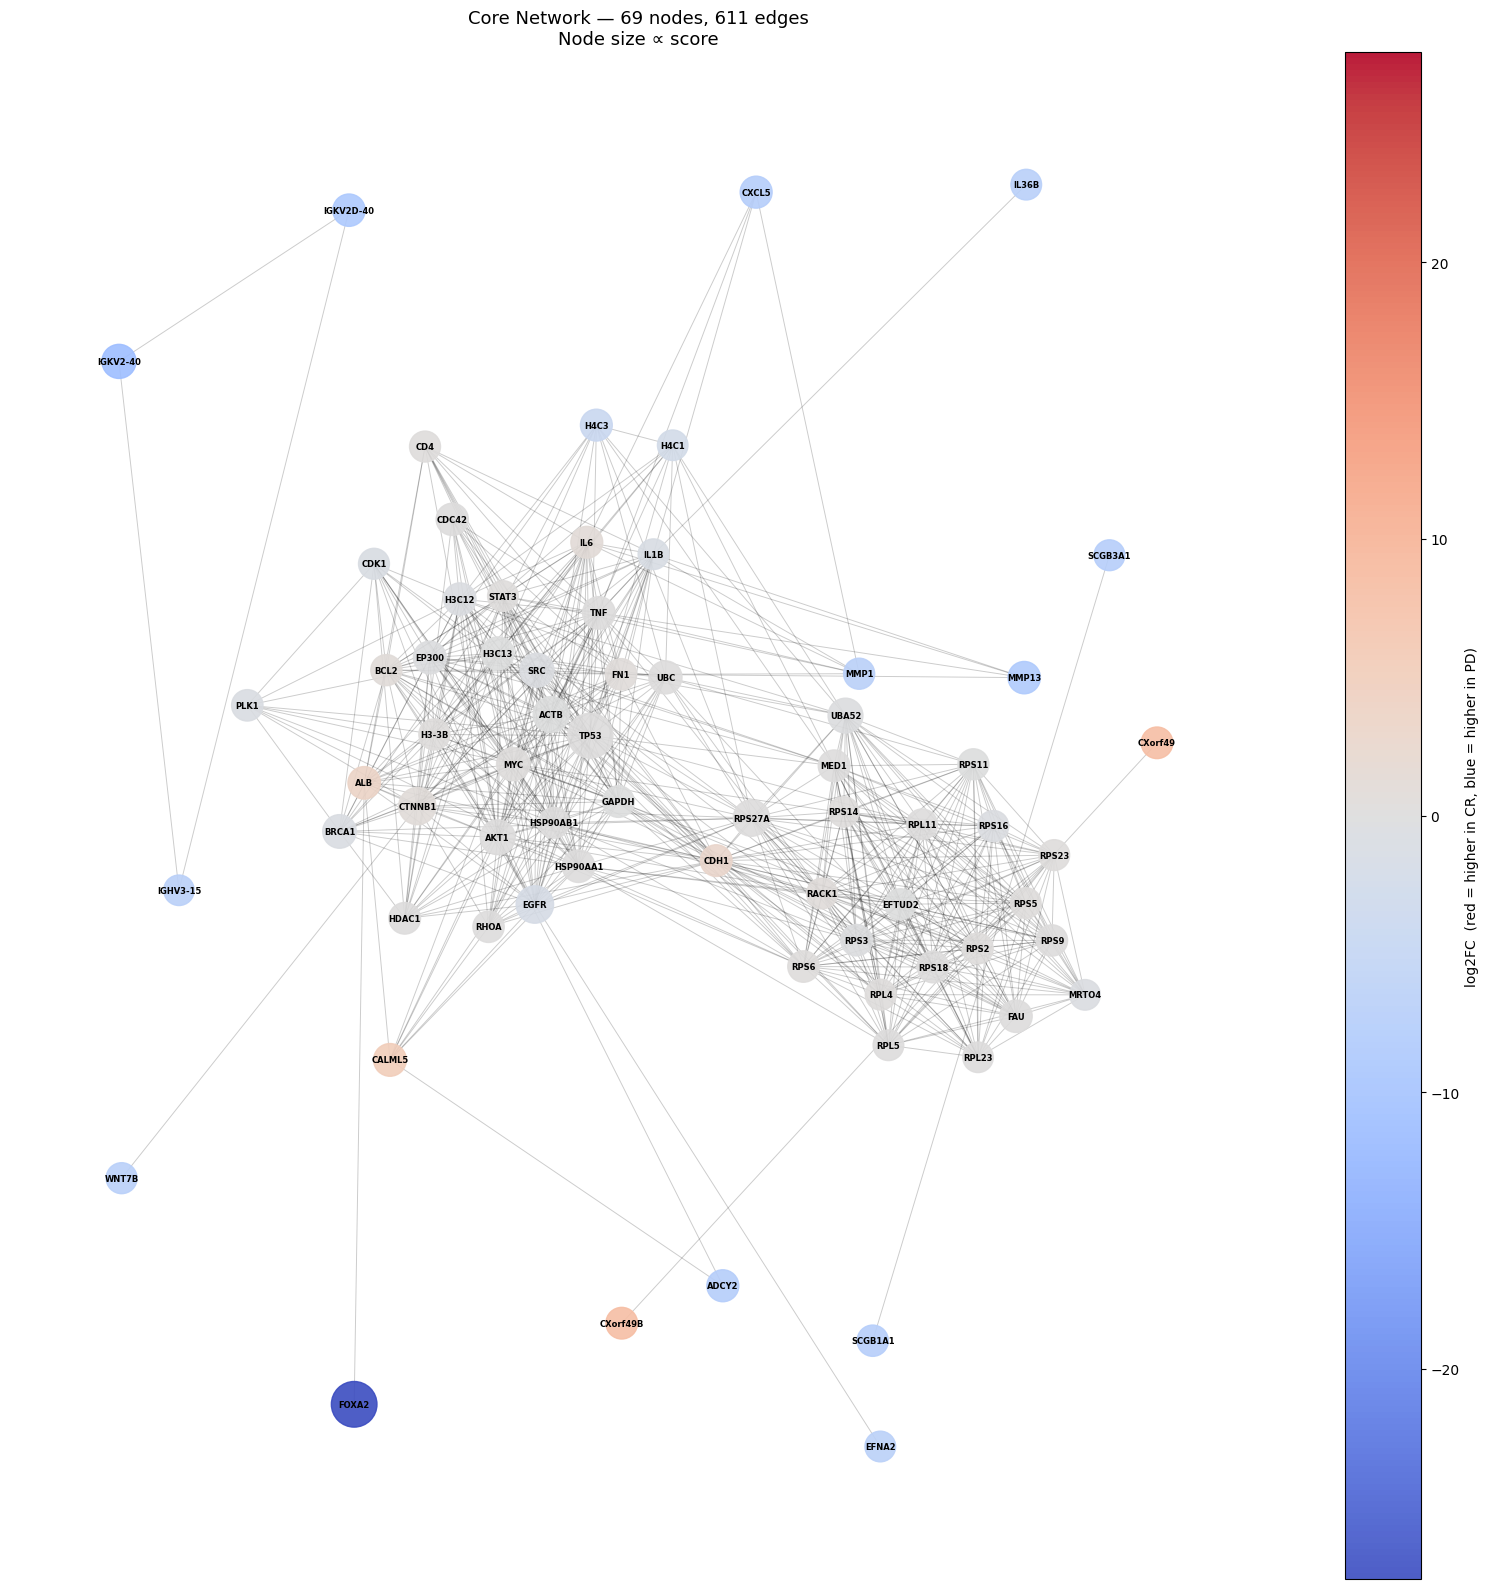

In [ ]:
fig, ax = plt.subplots(figsize=(16, 16))
pos = nx.spring_layout(core_net, seed=42, k=0.8)

# Collect per-node values in the order NetworkX uses them
node_list   = list(core_net.nodes())
node_colors = [id_to_log2fc.get(n, 0) for n in node_list]
node_sizes  = [300 + 1500 * id_to_score.get(n, 0) for n in node_list]

# Draw
sc = nx.draw_networkx_nodes(core_net, pos,
                             nodelist=node_list,
                             node_color=node_colors,
                             node_size=node_sizes,
                             cmap=plt.cm.coolwarm,
                             vmin=-max(abs(c) for c in node_colors),
                             vmax= max(abs(c) for c in node_colors),
                             alpha=0.9, ax=ax)
nx.draw_networkx_edges(core_net, pos, alpha=0.20, width=0.7, ax=ax)
nx.draw_networkx_labels(core_net, pos,
                         labels={n: id_to_symbol.get(n, n) for n in node_list},
                         font_size=6, font_weight="bold", ax=ax)

plt.colorbar(sc, ax=ax, label="log2FC  (red = higher in CR, blue = higher in PD)")
ax.set_title(f"Core Network — {n_nodes} nodes, {n_edges} edges\nNode size ∝ score", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("core_network.png", dpi=150)
plt.show() 

#### 7. Perform enrichment analysis for the nodes in the network.

In [ ]:
# Gene symbols of the core network nodes
core_gene_symbols = [id_to_symbol[n] for n in core_net.nodes() if n in id_to_symbol]
print(f"Genes submitted to Enrichr: {len(core_gene_symbols)}")
print(core_gene_symbols[:10], "...")

Genes submitted to Enrichr: 69
['IGKV2D-40', 'CXorf49', 'HSP90AA1', 'UBA52', 'CDC42', 'BCL2', 'MMP1', 'RPL4', 'RPS16', 'IL6'] ...


In [ ]:
# Query three complementary databases
databases = [
    "KEGG_2021_Human",            # broad pathway-level view
    "Reactome_2022",              # detailed mechanistic pathways
    "GO_Biological_Process_2023", # molecular function vocabulary
]

enrichment_results = {}

for db in databases:
    print(f"Querying {db} ...")
    enr = gp.enrichr(
        gene_list = core_gene_symbols,
        gene_sets = db,            # which database to query
        organism  = "Human",        
        outdir    = None,          # No output files written and results kept only in memory
        verbose   = False,         # No information printed to the console
    )
    enrichment_results[db] = enr.results
    sig = enr.results[enr.results["Adjusted P-value"] < 0.05]
    print(f"  Significant terms (adj.p < 0.05): {len(sig)}")
    print(enr.results[["Term","Adjusted P-value","Overlap"]].head(5).to_string(index=False))

Querying KEGG_2021_Human ...
  Significant terms (adj.p < 0.05): 152
                   Term  Adjusted P-value Overlap
    Coronavirus disease      1.526891e-25  23/232
               Ribosome      3.202919e-19  17/158
            Shigellosis      1.218313e-14  16/246
     Pathways in cancer      3.730123e-14  20/531
Proteoglycans in cancer      3.454849e-13  14/205
Querying Reactome_2022 ...
  Significant terms (adj.p < 0.05): 597
                                          Term  Adjusted P-value Overlap
         Peptide Chain Elongation R-HSA-156902      1.340122e-21   16/86
           Developmental Biology R-HSA-1266738      1.340122e-21 33/1073
      Signaling By ROBO Receptors R-HSA-376176      1.340122e-21  20/209
Eukaryotic Translation Elongation R-HSA-156842      1.340122e-21   16/90
Eukaryotic Translation Termination R-HSA-72764      1.340122e-21   16/90
Querying GO_Biological_Process_2023 ...
  Significant terms (adj.p < 0.05): 505
                                           Ter

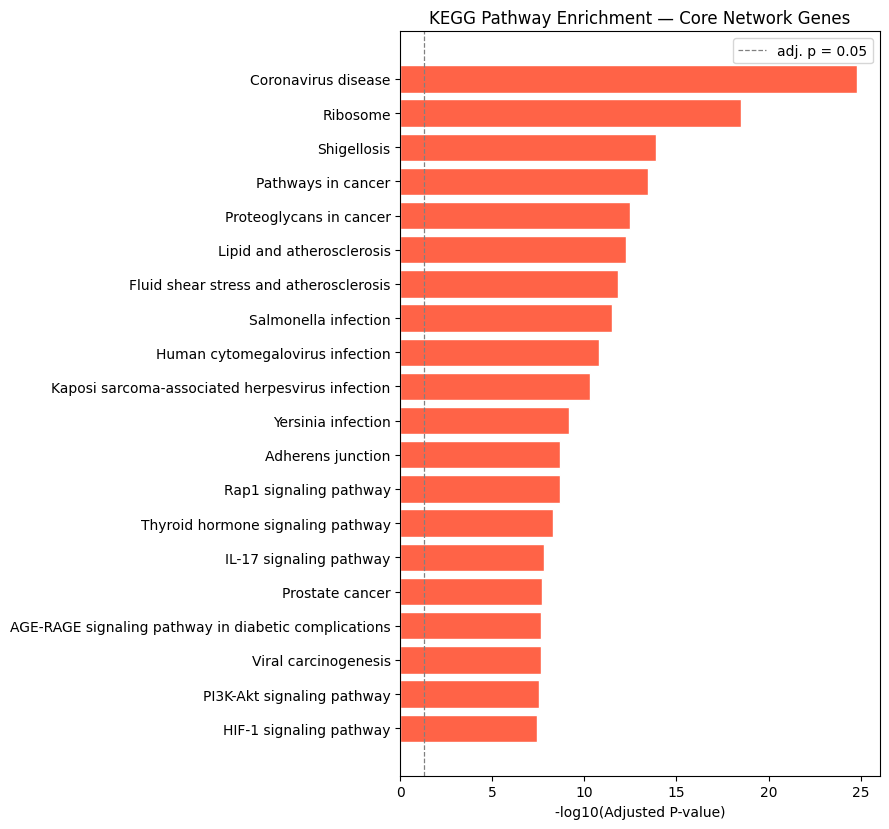

Saved: enrichment_KEGG.png


In [ ]:
# Bar plot of top KEGG terms 
kegg_df = enrichment_results["KEGG_2021_Human"].copy()
kegg_sig = kegg_df[kegg_df["Adjusted P-value"] < 0.05].head(20)

if kegg_sig.empty:
    print("No significant KEGG terms at adj.p < 0.05 — relaxing to p < 0.1")
    kegg_sig = kegg_df[kegg_df["P-value"] < 0.1].head(20)

if not kegg_sig.empty:
    kegg_sig = kegg_sig.copy()
    kegg_sig["-log10(Adj.P)"] = -np.log10(kegg_sig["Adjusted P-value"].clip(lower=1e-300))
    kegg_sorted = kegg_sig.sort_values("-log10(Adj.P)")

    fig, ax = plt.subplots(figsize=(9, max(4, len(kegg_sorted) * 0.42)))
    bars = ax.barh(kegg_sorted["Term"], kegg_sorted["-log10(Adj.P)"],
                   color="tomato", edgecolor="white")
    ax.axvline(x=-np.log10(0.05), color="grey", linestyle="--",
               linewidth=0.9, label="adj. p = 0.05")
    ax.set_xlabel("-log10(Adjusted P-value)")
    ax.set_title("KEGG Pathway Enrichment — Core Network Genes")
    ax.legend()
    plt.tight_layout()
    plt.savefig("enrichment_KEGG.png", dpi=150)
    plt.show()
    print("Saved: enrichment_KEGG.png")
else:
    print("No enriched KEGG terms found.")

In [ ]:
# Save all enrichment tables to CSV
outdir = "enrichment_results"
os.makedirs(outdir, exist_ok=True)

for db, df in enrichment_results.items():
    fname = f"{outdir}/enrichment_{db.replace(' ','_')}.csv"
    df.to_csv(fname, index=False)
    print(f"Saved: {fname}")

Saved: enrichment_results/enrichment_KEGG_2021_Human.csv
Saved: enrichment_results/enrichment_Reactome_2022.csv
Saved: enrichment_results/enrichment_GO_Biological_Process_2023.csv


#### 8. Use information from existing databases to find drugs targeting the genes in the core network.

In [ ]:
DGIDB_URL = "https://dgidb.org/api/graphql"

# GraphQL query — asks for all drugs targeting each gene
QUERY = """
query getDrugs($genes: [String!]!) {
  genes(names: $genes) {
    nodes {
      name
      interactions {
        drug {
          name
          approved
        }
        interactionScore
      }
    }
  }
}
"""

def query_dgidb(gene_list, batch_size=50):
    """
    Query DGIdb in batches to avoid URL-size limits.
    Returns a list of dicts, one per drug-gene pair.
    """
    all_records = []
    n_batches = (len(gene_list) + batch_size - 1) // batch_size
    for i in range(0, len(gene_list), batch_size):
        batch = gene_list[i : i + batch_size]
        batch_no = i // batch_size + 1
        print(f"  Batch {batch_no}/{n_batches}: querying {len(batch)} genes ...", end=" ")
        try:
            resp = requests.post(
                DGIDB_URL,
                json={"query": QUERY, "variables": {"genes": batch}},
                timeout=60,
            )
            if resp.status_code != 200:
                print(f"HTTP {resp.status_code} - skipping")
                continue
            data  = resp.json()
            nodes = data.get("data", {}).get("genes", {}).get("nodes", [])
            batch_hits = 0
            for gene_node in nodes:
                gene_name = gene_node["name"]
                for ix in gene_node.get("interactions", []):
                    drug_info = ix.get("drug") or {}
                    all_records.append({
                        "gene"             : gene_name,
                        "drug"             : drug_info.get("name", ""),
                        "approved"         : drug_info.get("approved", None),
                        "interaction_score": ix.get("interactionScore", None),
                    })
                    batch_hits += 1
            print(f"{batch_hits} interactions found")
        except Exception as e:
            print(f"Error: {e} — skipping batch")
        time.sleep(0.5)    # polite pause between requests
    return all_records

print("Querying DGIdb for drug-gene interactions ...")
dgi_records = query_dgidb(core_gene_symbols)
dgi_df = pd.DataFrame(dgi_records)

print(f"\nTotal drug-gene pairs found: {len(dgi_df)}")

Querying DGIdb for drug-gene interactions ...
  Batch 1/2: querying 50 genes ... 1166 interactions found
  Batch 2/2: querying 19 genes ... 932 interactions found

Total drug-gene pairs found: 2098


In [ ]:
if dgi_df.empty:
    print("No interactions found. Check that core_gene_symbols are official HGNC symbols.")
else:
    # Summary 
    approved_df = dgi_df[dgi_df["approved"] == True].copy()
    approved_df = approved_df.sort_values("interaction_score", ascending=False)

    print(f"Total drug-gene pairs          : {len(dgi_df)}")
    print(f"Approved-drug pairs only       : {len(approved_df)}")
    print(f"Unique approved drugs          : {approved_df['drug'].nunique()}")
    print(f"Core-network genes with a drug : {approved_df['gene'].nunique()}")

    print("\nTop 20 approved drug-gene interactions (by interaction score):")
    print(approved_df[["gene", "drug", "interaction_score"]].head(20).to_string(index=False))

Total drug-gene pairs          : 2098
Approved-drug pairs only       : 621
Unique approved drugs          : 421
Core-network genes with a drug : 46

Top 20 approved drug-gene interactions (by interaction score):
   gene                      drug  interaction_score
SCGB1A1                MECASERMIN          26.101899
    CD4                IBALIZUMAB           3.262737
   IL1B               CANAKINUMAB           2.559010
    TNF                 GOLIMUMAB           2.245325
    IL6                SILTUXIMAB           2.130767
   IL1B               PENTAMIDINE           2.047208
SCGB3A1                 PAZOPANIB           1.831712
  MMP13       DOXYCYCLINE CALCIUM           1.631369
 CTNNB1        FLUORESCEIN SODIUM           1.581933
   MMP1           INTERFERON BETA           1.305095
   CDH1              BICALUTAMIDE           1.305095
   EGFR                  AFATINIB           1.223527
    ALB    GADOFOSVESET TRISODIUM           1.186450
    ALB    GADOBENATE DIMEGLUMINE           1.

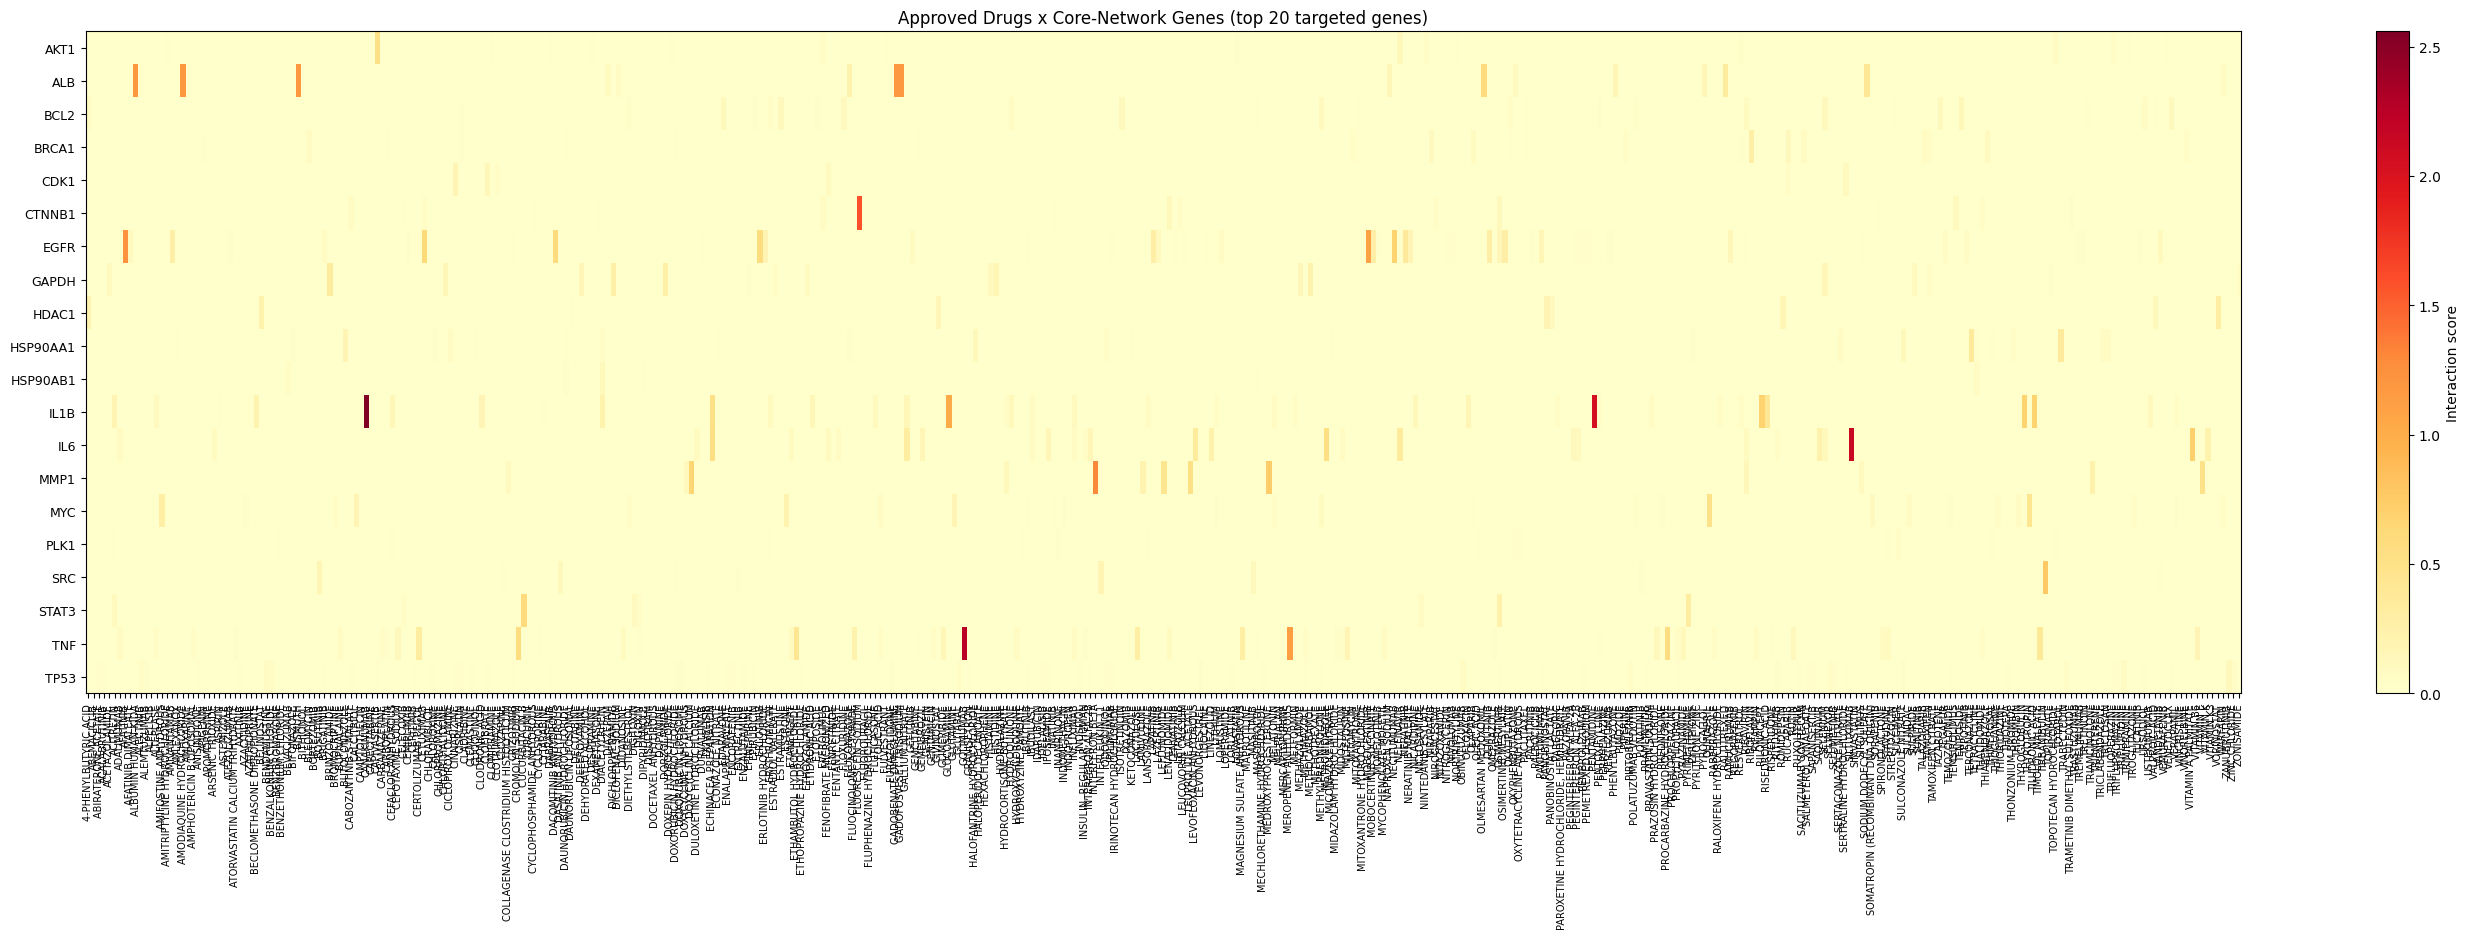

Saved: drug_gene_heatmap.png


In [ ]:
# Heatmap: approved drugs × core-network genes 
if not approved_df.empty:
    # Focus on the genes with the most drug interactions (top 20 for readability)
    top_targeted = (approved_df.groupby("gene")["drug"]
                    .nunique().nlargest(20).index.tolist())
    heat_data = (approved_df[approved_df["gene"].isin(top_targeted)]
                 .pivot_table(index="gene", columns="drug",
                              values="interaction_score", aggfunc="max")
                 .fillna(0))

    fig_h = max(5,  0.5 + len(heat_data) * 0.45)
    fig_w = min(28, 1   + len(heat_data.columns) * 0.45)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(heat_data.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(heat_data.columns)))
    ax.set_xticklabels(heat_data.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(heat_data.index)))
    ax.set_yticklabels(heat_data.index, fontsize=9)
    plt.colorbar(im, ax=ax, label="Interaction score")
    ax.set_title("Approved Drugs x Core-Network Genes (top 20 targeted genes)")
    plt.tight_layout()
    plt.savefig("drug_gene_heatmap.png", dpi=150)
    plt.show()
    print("Saved: drug_gene_heatmap.png")

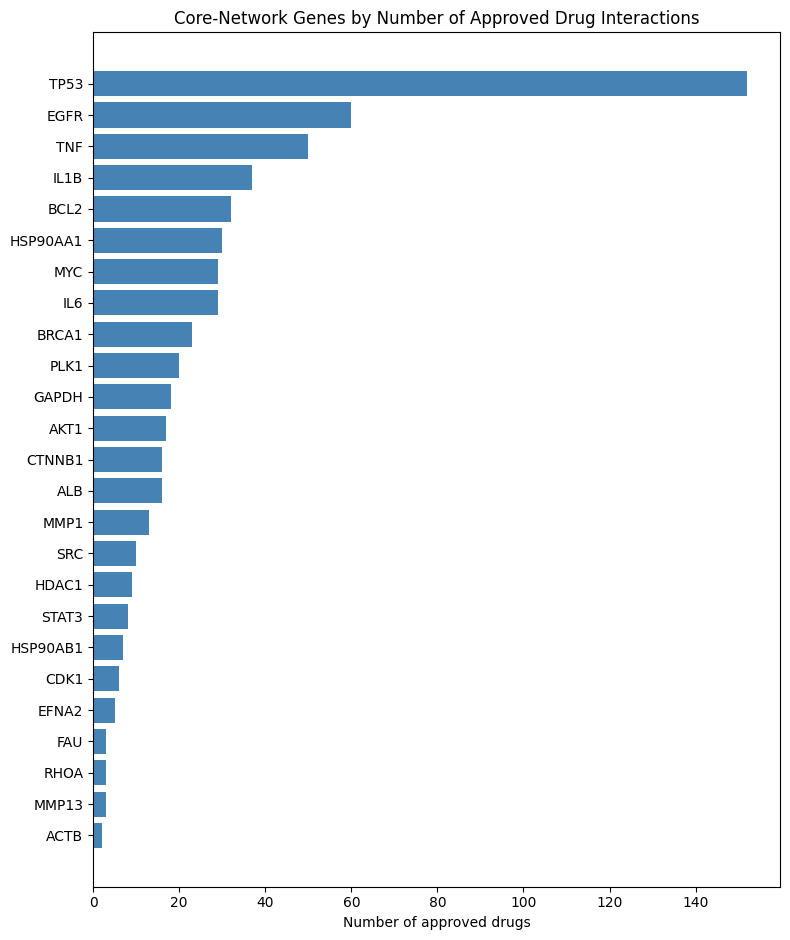

Saved: drugs_per_gene.png
Saved: drug_gene_interactions_all.csv
Saved: drug_gene_interactions_approved.csv


In [ ]:
# How many approved drugs hit each core-network gene? 
drug_count_per_gene = (approved_df.groupby("gene")["drug"]
                       .nunique().sort_values(ascending=False).head(25))

fig, ax = plt.subplots(figsize=(8, max(4, len(drug_count_per_gene) * 0.38)))
ax.barh(drug_count_per_gene.index[::-1], drug_count_per_gene.values[::-1],
        color="steelblue")
ax.set_xlabel("Number of approved drugs")
ax.set_title("Core-Network Genes by Number of Approved Drug Interactions")
plt.tight_layout()
plt.savefig("drugs_per_gene.png", dpi=150)
plt.show()
print("Saved: drugs_per_gene.png")

# Save tables 
dgi_df.to_csv("drug_gene_interactions_all.csv", index=False)
approved_df.to_csv("drug_gene_interactions_approved.csv", index=False)
print("Saved: drug_gene_interactions_all.csv")
print("Saved: drug_gene_interactions_approved.csv")